In [1]:
import torch
from model.model import EncoderDecoderDAG
from utils.data import TranslateDataset, collate_fn, process_data

In [2]:
from torch.utils.data import DataLoader
from utils.load_tokenizer import load_tokenizer

g:\Projects\Visual Studio Code\LMTests\lmtest\lib\site-packages\transformers\utils\hub.py:123: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [3]:
tokenizer, vocab_size = load_tokenizer()

In [4]:
data_dir = "data"
data_file = "processed.pt"

In [5]:
ds = TranslateDataset(data_dir, data_file)

Loading data from data\processed.pt


In [6]:
batch_size = 8

In [7]:
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

In [8]:
# sample = next(iter(dl))

In [9]:
# ens, zhs = sample

In [10]:
pad_idx = tokenizer.pad_token_id

In [11]:
factor = 4
emb_size = 256
num_heads = 8
max_seq_len = 100
max_vertices = max_seq_len * factor

In [12]:
layers = [(2,2), 1, (1,1)]
out_layers = 1

In [13]:
model = EncoderDecoderDAG(vocab_size, emb_size, num_heads, max_seq_len, max_vertices, layers, out_layers)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
device

device(type='cuda')

In [16]:
model = model.to(device)

In [17]:
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")

Model has 27100744 trainable parameters


In [18]:
from torch.optim import Adam

In [19]:
optm = Adam(model.parameters(), lr=1e-3)

In [20]:
dl_iter = iter(dl)

In [21]:
from losses.dag_loss import dag_loss

In [22]:
from tqdm.notebook import tqdm

In [23]:
losses = []

In [24]:
epochs = 900
for i in (pbar := tqdm(range(epochs))):
    try:
        ens, zhs = next(dl_iter)
    except StopIteration:
        dl_iter = iter(dl)
        ens, zhs = next(dl_iter)
    
    ens, zhs = ens.to(device), zhs.to(device)
    batch_size, l = ens.shape
    decoder_tokens = torch.arange(0, l * factor).unsqueeze(0).expand(batch_size, -1).to(device)
    target_lens, _, _, _ = process_data(zhs, pad_idx, factor)
    token_lens, vertex_lens, token_mask, vertex_mask = process_data(ens, pad_idx, factor)

    optm.zero_grad()
    log_transition_probs, log_emission_probs = model(ens, decoder_tokens, token_mask, vertex_mask)
    loss = dag_loss(zhs, log_transition_probs, log_emission_probs, target_lens, vertex_lens)
    loss.backward()
    optm.step()
    losses.append(loss.item())
    pbar.set_description(f"Loss: {loss.item():.4f}")

  0%|          | 0/900 [00:00<?, ?it/s]

In [27]:
from matplotlib import pyplot as plt

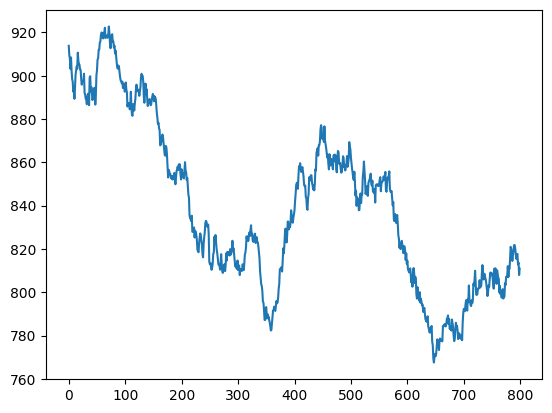

In [28]:
window_size = 100
plt.plot([sum(losses[i:i+window_size])/window_size for i in range(len(losses) - window_size)])